# Week 4 – Supervised Learning Model Implementation

**Problem:** Binary classification of malignant vs benign breast tumors using the Breast Cancer Wisconsin (Diagnostic) dataset.

**Model:** Logistic Regression with imputation and standardization.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve

ROOT = Path('..') if Path('..').exists() else Path('.')
DATA = ROOT / 'dataset' / 'breast_cancer.csv'
df = pd.read_csv(DATA)
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


## 1. Data inspection


In [2]:
print(df.shape)
print(df.isna().sum().sum())
print(df['target'].value_counts())


(569, 31)
0
target
0    357
1    212
Name: count, dtype: int64


## 2. Prepare features and target


In [3]:
feature_cols = [c for c in df.columns if c != 'target']
X = df[feature_cols]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)


(455, 30) (114, 30)


## 3. Preprocessing and model training

Median imputation is included for robustness, while StandardScaler makes the numeric features comparable and supports stable Logistic Regression optimization.


In [4]:
model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=5000, random_state=42))
])
model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

## 4. Five-fold stratified cross-validation


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    model, X_train, y_train, cv=cv,
    scoring=['accuracy','precision','recall','f1','roc_auc']
)
cv_summary = pd.DataFrame({
    'Metric':['Accuracy','Precision','Recall','F1 Score','ROC-AUC'],
    'Mean':[cv_results['test_accuracy'].mean(), cv_results['test_precision'].mean(), cv_results['test_recall'].mean(), cv_results['test_f1'].mean(), cv_results['test_roc_auc'].mean()],
    'Std':[cv_results['test_accuracy'].std(), cv_results['test_precision'].std(), cv_results['test_recall'].std(), cv_results['test_f1'].std(), cv_results['test_roc_auc'].std()]
})
cv_summary


,Metric,Mean,Std
0,Accuracy,0.973626,0.014906
1,Precision,0.977143,0.027994
2,Recall,0.952941,0.039896
3,F1 Score,0.964048,0.020700
4,ROC-AUC,0.995769,0.004666


## 5. Held-out test evaluation


In [6]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_prob)
}
pd.Series(metrics)


Accuracy     0.964912
Precision    0.975000
Recall       0.928571
F1 Score     0.951220
ROC-AUC      0.996032
dtype: float64

## 6. Confusion matrix and diagnostic plots


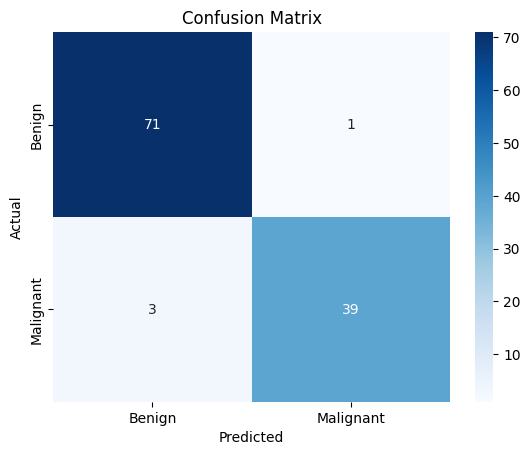

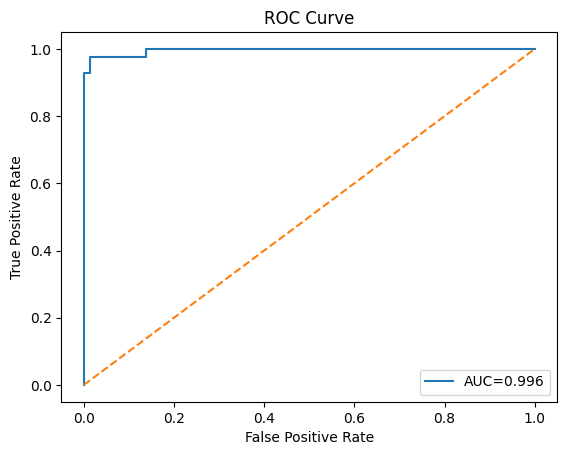

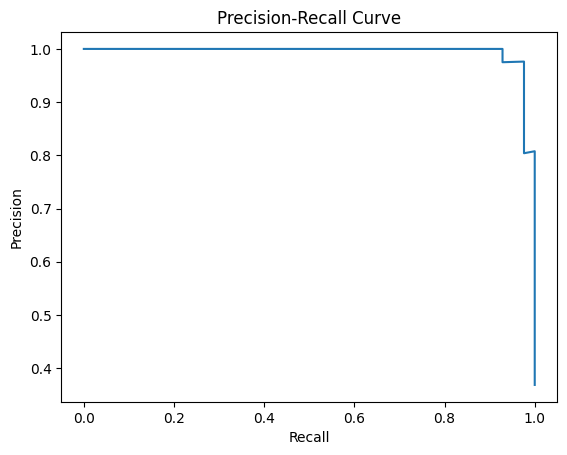

In [7]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign','Malignant'], yticklabels=['Benign','Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'AUC={metrics["ROC-AUC"]:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve'); plt.legend(); plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.plot(recall, precision)
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall Curve'); plt.show()


## 7. Feature interpretation


In [8]:
coef = model.named_steps['classifier'].coef_[0]
importance = pd.DataFrame({'feature':feature_cols,'coefficient':coef,'abs_coefficient':np.abs(coef)}).sort_values('abs_coefficient', ascending=False)
importance.head(12)


,feature,coefficient,abs_coefficient
21,worst texture,1.434093,1.434093
10,radius error,1.233325,1.233325
28,worst symmetry,1.061264,1.061264
7,mean concave points,0.952813,0.952813
26,worst concavity,0.911406,0.911406
13,area error,0.909029,0.909029
15,compactness error,-0.906925,0.906925
23,worst area,0.900477,0.900477
20,worst radius,0.896968,0.896968
6,mean concavity,0.782298,0.782298


## 8. Save results


In [9]:
OUT = ROOT / 'results'
OUT.mkdir(exist_ok=True)
pd.DataFrame({'Metric':list(metrics.keys()), 'Test_Set_Score':list(metrics.values())}).to_csv(OUT/'test_metrics.csv', index=False)
cv_summary.to_csv(OUT/'cross_validation_metrics.csv', index=False)
pd.DataFrame(confusion_matrix(y_test, y_pred)).to_csv(OUT/'confusion_matrix.csv', index=False)
pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T.to_csv(OUT/'classification_report.csv')
importance.to_csv(OUT/'feature_coefficients.csv', index=False)
print('Saved results to', OUT.resolve())


Saved results to /mnt/data/week4_pkg/Week_4_Task/results
